In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.mixture import GaussianMixture

In [2]:
df = pd.read_csv('dataset.csv')

### Data Preprocessing

In [3]:
df['artists'] = df['artists'].fillna('Unknown Artist')
df['album_name'] = df['album_name'].fillna('Unknown Album')
df['track_name'] = df['track_name'].fillna('Unknown Track')

Business Insights: Clustering artist

In [4]:
artist_features = df.groupby('artists')[[
    'valence', 'energy', 'danceability', 'tempo', 'acousticness',
    'instrumentalness', 'loudness', 'speechiness', 'liveness'
]].mean().reset_index()

# artist_features

In [5]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(artist_features.drop('artists', axis=1))

K-Mean

In [6]:
# # Range of possible clusters
# k_range = range(1, 11)
# wcss = []

# # Loop through different values of k
# for k in k_range:
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     kmeans.fit(scaled_features)  # Use scaled features for clustering
#     wcss.append(kmeans.inertia_)

# # Plot the Elbow curve
# plt.figure(figsize=(8, 6))
# plt.plot(k_range, wcss, marker='o')
# plt.title('Elbow Method for Optimal k')
# plt.xlabel('Number of Clusters')
# plt.ylabel('WCSS (Inertia)')
# plt.grid(True)
# plt.show()

In [7]:
# silhouette_scores = []

# for k in range(2, 11):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     cluster_labels = kmeans.fit_predict(scaled_features)
#     score = silhouette_score(scaled_features, cluster_labels)
#     silhouette_scores.append(score)

# # Plot Silhouette Scores
# plt.figure(figsize=(8, 6))
# plt.plot(range(2, 11), silhouette_scores, marker='o')
# plt.title('Silhouette Score for Optimal k')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Silhouette Score')
# plt.grid(True)
# plt.show()

# # Print the best k based on the highest silhouette score
# best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
# print(f"Best k based on Silhouette Score: {best_k}")

In [8]:
# Cluster = 7
kmeans = KMeans(n_clusters=7, random_state=42)
artist_features['km_cluster'] = kmeans.fit_predict(scaled_features)

silhouette_avg = silhouette_score(scaled_features, artist_features['km_cluster'])
print(f'Silhouette Score: {silhouette_avg:.4f}')

dbi_score = davies_bouldin_score(scaled_features, artist_features['km_cluster'])
print(f'Davies-Bouldin Index: {dbi_score:.4f}')

def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    # Intra-cluster distances (diameter)
    intra_dists = []
    for cluster in unique_clusters:
        cluster_points = X[labels == cluster]
        if len(cluster_points) > 1:
            distances = cdist(cluster_points, cluster_points)
            intra_dists.append(np.max(distances))
        else:
            intra_dists.append(0)

    max_intra = np.max(intra_dists)

    # Inter-cluster distances (minimum distance between clusters)
    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = X[labels == unique_clusters[i]]
            cluster_j = X[labels == unique_clusters[j]]
            distance = cdist(cluster_i, cluster_j)
            inter_dists.append(np.min(distance))

    min_inter = np.min(inter_dists)

    # Dunn Index
    if max_intra == 0:
        return 0
    return min_inter / max_intra

dunn = dunn_index(scaled_features, artist_features['km_cluster'])
print(f"Dunn Index: {dunn:.4f}")

def calculate_wcss(X, y_pred):
    wcss = 0
    for cluster in np.unique(y_pred):
        cluster_points = X[y_pred == cluster]
        cluster_center = np.mean(cluster_points, axis=0)
        wcss += np.sum((cluster_points - cluster_center) ** 2)
    return wcss

wcss = calculate_wcss(scaled_features, artist_features['km_cluster'])
print(f'Within-Cluster Sum of Squares (WCSS): {wcss}')

Silhouette Score: 0.1887
Davies-Bouldin Index: 1.4044
Dunn Index: 0.0161
Within-Cluster Sum of Squares (WCSS): 136856.93576028277


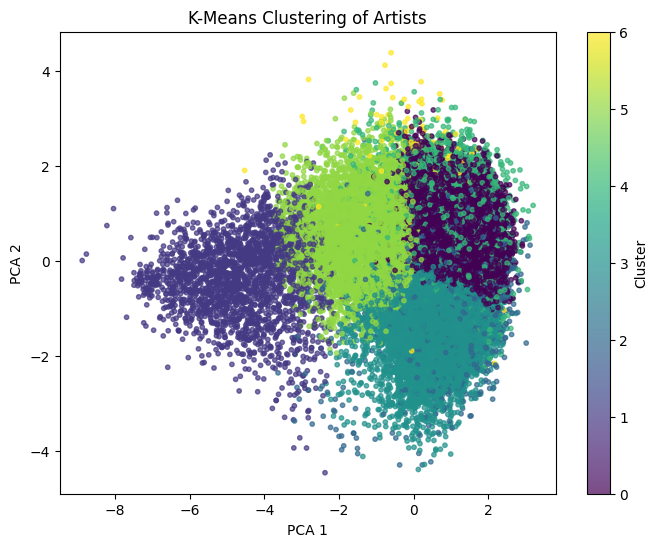

In [9]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=artist_features['km_cluster'], alpha=0.7, s=10)  # s=10 makes dots smaller
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering of Artists')
plt.colorbar(label='Cluster')
plt.show()

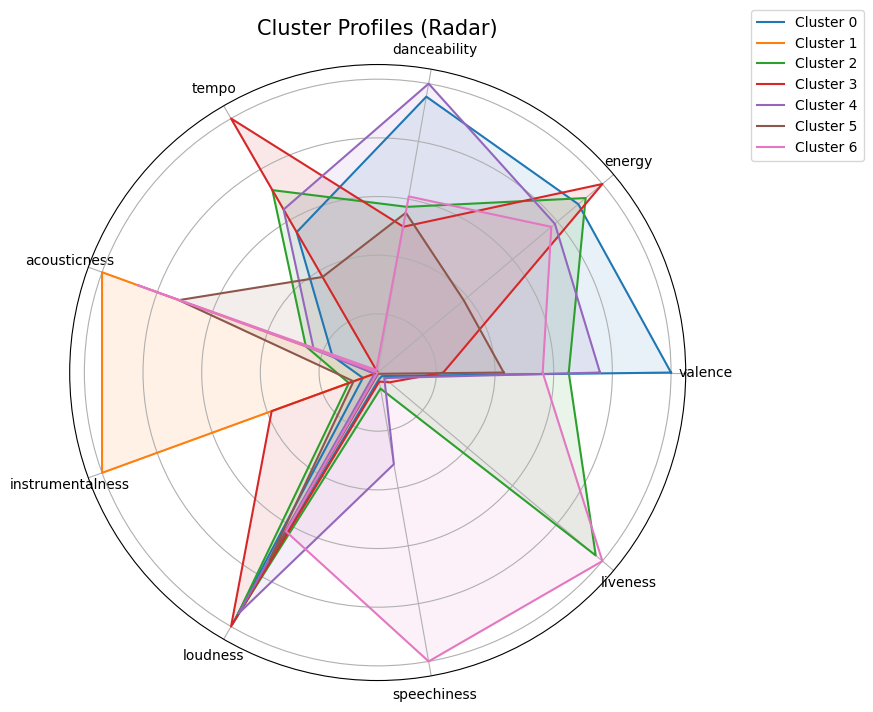

In [10]:
# Calculate cluster profiles (mean of each feature by cluster)
cluster_profiles = artist_features.groupby('km_cluster').mean(numeric_only=True)

# Select a few important features for visualization
features_to_plot = ['valence', 'energy', 'danceability', 'tempo', 'acousticness',
    'instrumentalness', 'loudness', 'speechiness', 'liveness']
cluster_profiles = cluster_profiles[features_to_plot]

# Normalize values between 0 and 1 for radar plot clarity
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_profiles = scaler.fit_transform(cluster_profiles)
scaled_profiles_df = pd.DataFrame(scaled_profiles, columns=features_to_plot)

# Radar plot function
def radar_plot(data, labels, title='Cluster Profiles (Radar)'):
    num_vars = len(data.columns)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # repeat the first angle to close the circle

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for i, row in data.iterrows():
        values = row.tolist()
        values += values[:1]  # repeat first value
        ax.plot(angles, values, label=f'Cluster {i}')
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(data.columns)
    ax.set_yticklabels([])
    ax.set_title(title, size=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Plot radar chart
radar_plot(scaled_profiles_df, scaled_profiles_df.index)


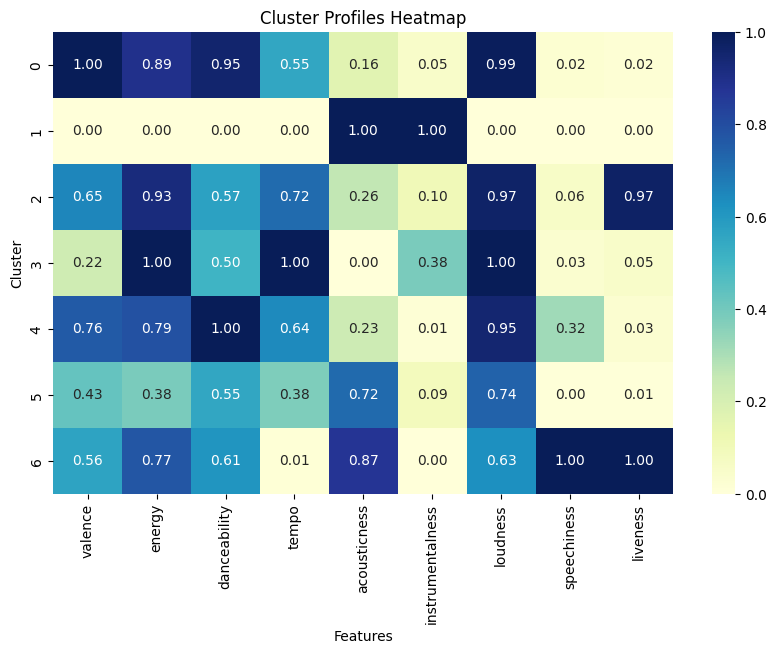

In [11]:
feature_names = [
    'valence', 'energy', 'danceability', 'tempo', 'acousticness',
    'instrumentalness', 'loudness', 'speechiness', 'liveness'
]
scaled_profiles_df.columns = feature_names

plt.figure(figsize=(10, 6))
sns.heatmap(scaled_profiles_df, cmap='YlGnBu', annot=True, fmt='.2f')
plt.title('Cluster Profiles Heatmap')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.show()

GMM

In [12]:
# aic = []
# bic = []
# n_components_range = range(1, 11)

# for k in n_components_range:
#     gmm = GaussianMixture(n_components=k, random_state=42)
#     gmm.fit(scaled_features)
#     aic.append(gmm.aic(scaled_features))
#     bic.append(gmm.bic(scaled_features))

# # Plot AIC and BIC
# plt.figure(figsize=(8, 6))
# plt.plot(n_components_range, aic, label='AIC', marker='o')
# plt.plot(n_components_range, bic, label='BIC', marker='o')
# plt.xlabel('Number of Components')
# plt.ylabel('Information Criterion')
# plt.title('AIC and BIC for GMM Clustering')
# plt.legend()
# plt.grid(True)
# plt.show()


In [13]:
# silhouette_scores = []
# for k in range(2, 11):
#     gmm = GaussianMixture(n_components=k, random_state=42)
#     labels = gmm.fit_predict(scaled_features)
#     score = silhouette_score(scaled_features, labels)
#     silhouette_scores.append(score)

# plt.figure(figsize=(8, 6))
# plt.plot(range(2, 11), silhouette_scores, marker='o')
# plt.title('Silhouette Score for GMM')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Silhouette Score')
# plt.grid(True)
# plt.show()

# # Best k
# best_k_silhouette = range(2, 11)[np.argmax(silhouette_scores)]
# print(f"Best k based on Silhouette Score: {best_k_silhouette}")


In [14]:
gmm = GaussianMixture(n_components=3, random_state=42)
artist_features['gmm_cluster'] = gmm.fit_predict(scaled_features)

silhouette_avg = silhouette_score(scaled_features, artist_features['gmm_cluster'])
print(f'Silhouette Score: {silhouette_avg:.4f}')

dbi_score = davies_bouldin_score(scaled_features, artist_features['gmm_cluster'])
print(f'Davies-Bouldin Index: {dbi_score:.4f}')

def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    # Intra-cluster distances (diameter)
    intra_dists = []
    for cluster in unique_clusters:
        cluster_points = X[labels == cluster]
        if len(cluster_points) > 1:
            distances = cdist(cluster_points, cluster_points)
            intra_dists.append(np.max(distances))
        else:
            intra_dists.append(0)

    max_intra = np.max(intra_dists)

    # Inter-cluster distances (minimum distance between clusters)
    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = X[labels == unique_clusters[i]]
            cluster_j = X[labels == unique_clusters[j]]
            distance = cdist(cluster_i, cluster_j)
            inter_dists.append(np.min(distance))

    min_inter = np.min(inter_dists)

    # Dunn Index
    if max_intra == 0:
        return 0
    return min_inter / max_intra

dunn = dunn_index(scaled_features, artist_features['gmm_cluster'])
print(f"Dunn Index: {dunn:.4f}")

def calculate_wcss(X, y_pred):
    wcss = 0
    for cluster in np.unique(y_pred):
        cluster_points = X[y_pred == cluster]
        cluster_center = np.mean(cluster_points, axis=0)
        wcss += np.sum((cluster_points - cluster_center) ** 2)
    return wcss

wcss = calculate_wcss(scaled_features, artist_features['gmm_cluster'])
print(f'Within-Cluster Sum of Squares (WCSS): {wcss}')

Silhouette Score: 0.0568
Davies-Bouldin Index: 2.4225
Dunn Index: 0.0094
Within-Cluster Sum of Squares (WCSS): 237427.11362898588


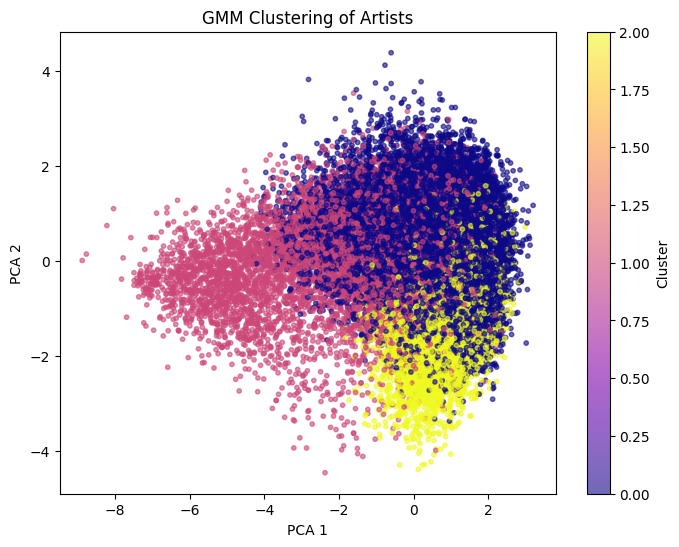

In [15]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=artist_features['gmm_cluster'], cmap='plasma', s=10, alpha=0.6)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('GMM Clustering of Artists')
plt.colorbar(label='Cluster')
plt.show()

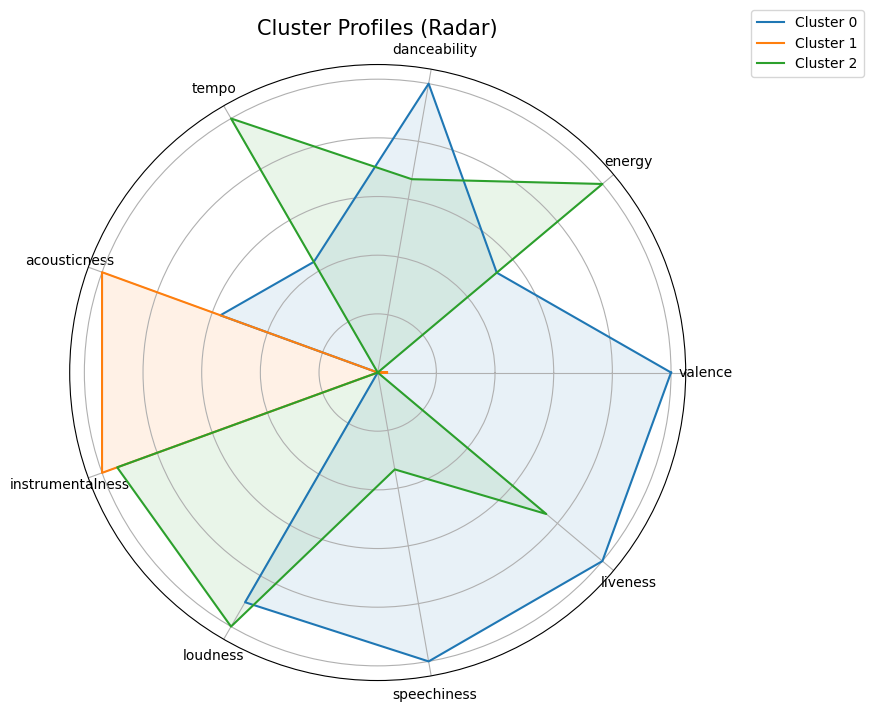

In [16]:
# Calculate cluster profiles (mean of each feature by cluster)
cluster_profiles = artist_features.groupby('gmm_cluster').mean(numeric_only=True)

# Select a few important features for visualization
features_to_plot = ['valence', 'energy', 'danceability', 'tempo', 'acousticness',
    'instrumentalness', 'loudness', 'speechiness', 'liveness']
cluster_profiles = cluster_profiles[features_to_plot]

# Normalize values between 0 and 1 for radar plot clarity
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_profiles = scaler.fit_transform(cluster_profiles)
scaled_profiles_df = pd.DataFrame(scaled_profiles, columns=features_to_plot)

# Radar plot function
def radar_plot(data, labels, title='Cluster Profiles (Radar)'):
    num_vars = len(data.columns)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # repeat the first angle to close the circle

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for i, row in data.iterrows():
        values = row.tolist()
        values += values[:1]  # repeat first value
        ax.plot(angles, values, label=f'Cluster {i}')
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(data.columns)
    ax.set_yticklabels([])
    ax.set_title(title, size=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Plot radar chart
radar_plot(scaled_profiles_df, scaled_profiles_df.index)


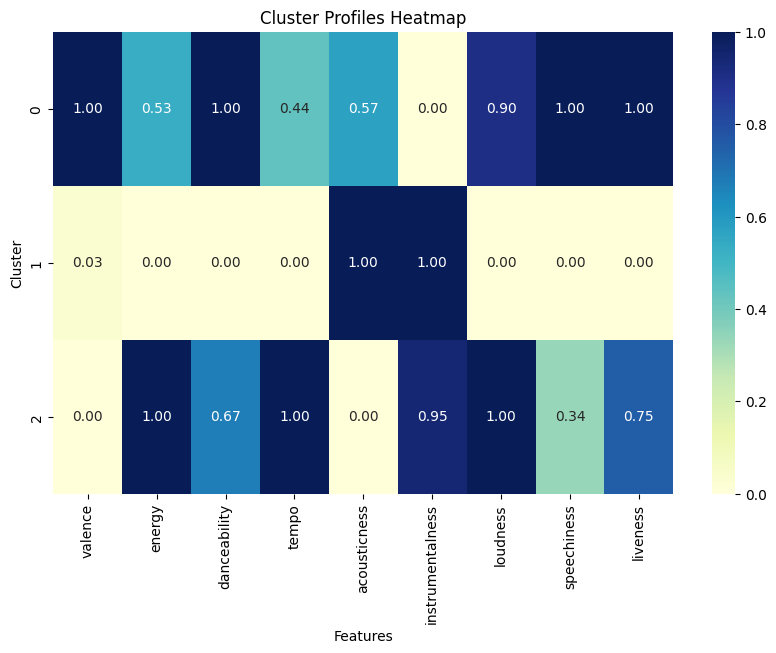

In [17]:
feature_names = [
    'valence', 'energy', 'danceability', 'tempo', 'acousticness',
    'instrumentalness', 'loudness', 'speechiness', 'liveness'
]
scaled_profiles_df.columns = feature_names

plt.figure(figsize=(10, 6))
sns.heatmap(scaled_profiles_df, cmap='YlGnBu', annot=True, fmt='.2f')
plt.title('Cluster Profiles Heatmap')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.show()


In [6]:
# K = 7
gmm = GaussianMixture(n_components=7, random_state=42)
artist_features['gmm_cluster'] = gmm.fit_predict(scaled_features)

silhouette_avg = silhouette_score(scaled_features, artist_features['gmm_cluster'])
print(f'Silhouette Score: {silhouette_avg:.4f}')

dbi_score = davies_bouldin_score(scaled_features, artist_features['gmm_cluster'])
print(f'Davies-Bouldin Index: {dbi_score:.4f}')

def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    # Intra-cluster distances (diameter)
    intra_dists = []
    for cluster in unique_clusters:
        cluster_points = X[labels == cluster]
        if len(cluster_points) > 1:
            distances = cdist(cluster_points, cluster_points)
            intra_dists.append(np.max(distances))
        else:
            intra_dists.append(0)

    max_intra = np.max(intra_dists)

    # Inter-cluster distances (minimum distance between clusters)
    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = X[labels == unique_clusters[i]]
            cluster_j = X[labels == unique_clusters[j]]
            distance = cdist(cluster_i, cluster_j)
            inter_dists.append(np.min(distance))

    min_inter = np.min(inter_dists)

    # Dunn Index
    if max_intra == 0:
        return 0
    return min_inter / max_intra

dunn = dunn_index(scaled_features, artist_features['gmm_cluster'])
print(f"Dunn Index: {dunn:.4f}")

def calculate_wcss(X, y_pred):
    wcss = 0
    for cluster in np.unique(y_pred):
        cluster_points = X[y_pred == cluster]
        cluster_center = np.mean(cluster_points, axis=0)
        wcss += np.sum((cluster_points - cluster_center) ** 2)
    return wcss

wcss = calculate_wcss(scaled_features, artist_features['gmm_cluster'])
print(f'Within-Cluster Sum of Squares (WCSS): {wcss}')

Silhouette Score: 0.0233
Davies-Bouldin Index: 4.9895
Dunn Index: 0.0096
Within-Cluster Sum of Squares (WCSS): 201516.39918497705
